In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error

# Cargar datasets
df_train = pd.read_csv('train.csv')
df_competition = pd.read_csv('Competition.csv')  # Sin columna 'price'

# Visualización inicial del train
print("Primeras 5 filas del dataset de entrenamiento:")
display(df_train.head())

print("\nInformación general del dataset de entrenamiento:")
df_train.info()

print("\nDescripción estadística del dataset de entrenamiento:")
display(df_train.describe(include='all'))



Primeras 5 filas del dataset de entrenamiento:


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,make,price
0,Polo,2017,Manual,36874,Petrol,20.0,60.1,1.2,vw,10250
1,Fabia,2016,Manual,39386,Petrol,20.0,60.1,1.2,skoda,8250
2,Grandland X,2018,Automatic,8935,Diesel,145.0,57.7,1.5,vauxhall,16299
3,Fiesta,2016,Manual,18606,Petrol,20.0,62.8,1.0,ford,10199
4,Octavia,2015,Manual,26000,Diesel,30.0,61.4,2.0,skoda,12790



Información general del dataset de entrenamiento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75978 entries, 0 to 75977
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         75978 non-null  object 
 1   year          75978 non-null  int64  
 2   transmission  75978 non-null  object 
 3   mileage       75978 non-null  int64  
 4   fuelType      75978 non-null  object 
 5   tax           69449 non-null  float64
 6   mpg           69449 non-null  float64
 7   engineSize    75978 non-null  float64
 8   make          75978 non-null  object 
 9   price         75978 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 5.8+ MB

Descripción estadística del dataset de entrenamiento:


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,make,price
count,75978,75978.000000,75978,75978.000000,75978,69449.000000,69449.00000,75978.000000,75978,75978.000000
unique,192,NaN,4,NaN,5,NaN,NaN,NaN,9,NaN
top,Focus,NaN,Manual,NaN,Petrol,NaN,NaN,NaN,ford,NaN
freq,6964,NaN,42749,NaN,41763,NaN,NaN,NaN,16313,NaN
mean,NaN,2017.100319,NaN,22967.622983,NaN,120.572362,55.19451,1.663712,NaN,16925.649543
std,NaN,2.127747,NaN,21024.729721,NaN,63.192927,16.46193,0.555865,NaN,9728.759207
min,NaN,1970.000000,NaN,1.000000,NaN,0.000000,0.30000,0.000000,NaN,450.000000
25%,NaN,2016.000000,NaN,7470.250000,NaN,125.000000,47.00000,1.200000,NaN,10277.000000
50%,NaN,2017.000000,NaN,17265.500000,NaN,145.000000,54.30000,1.600000,NaN,14750.000000
75%,NaN,2019.000000,NaN,32221.500000,NaN,145.000000,62.80000,2.000000,NaN,20980.000000


Valores faltantes por columna (train):
model              0
year               0
transmission       0
mileage            0
fuelType           0
tax             6529
mpg             6529
engineSize         0
make               0
price              0
dtype: int64

Número de filas duplicadas: 1319
Tamaño del dataset después de eliminar duplicados: (74659, 10)


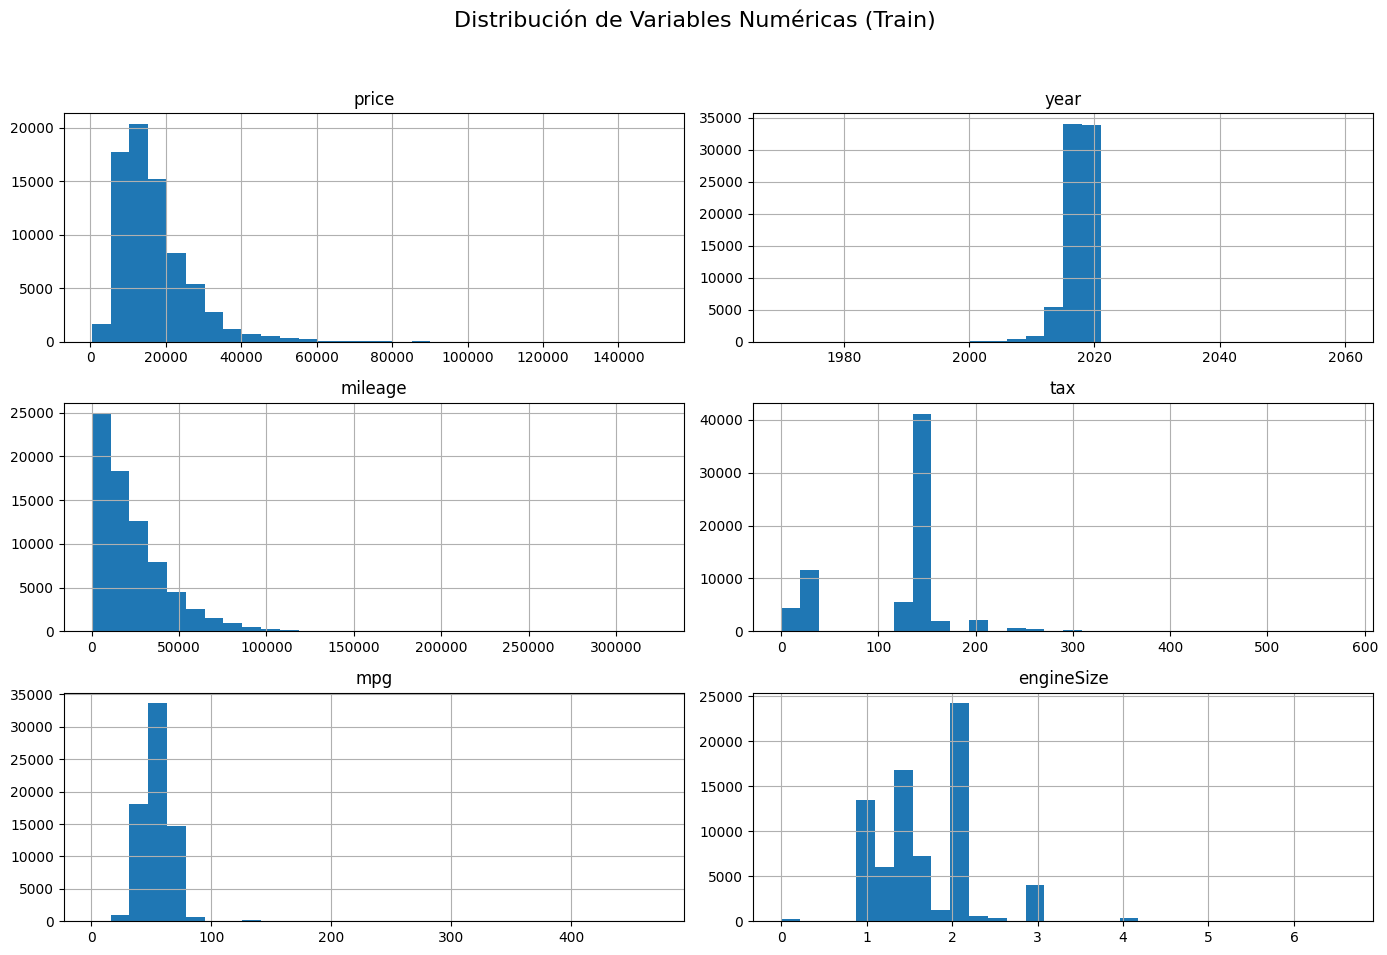

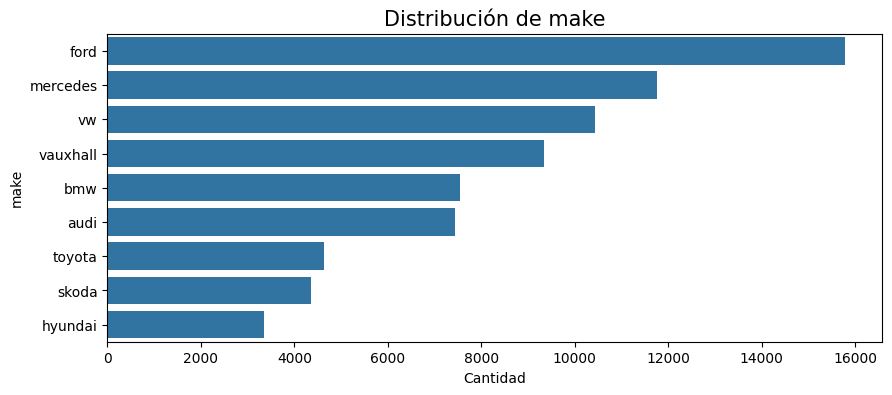

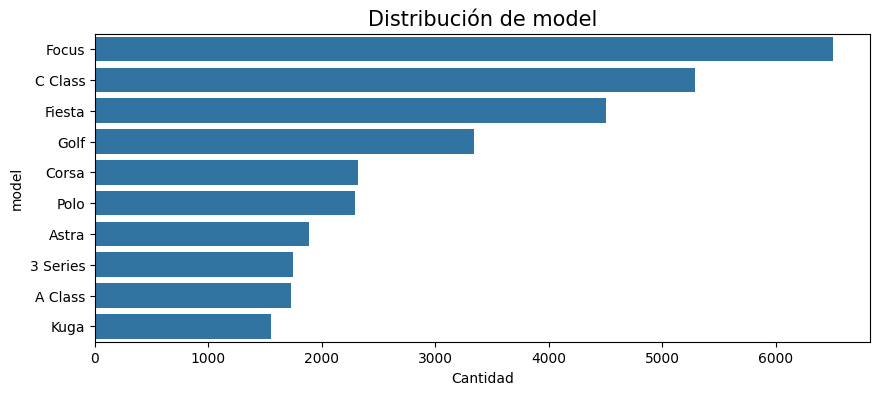

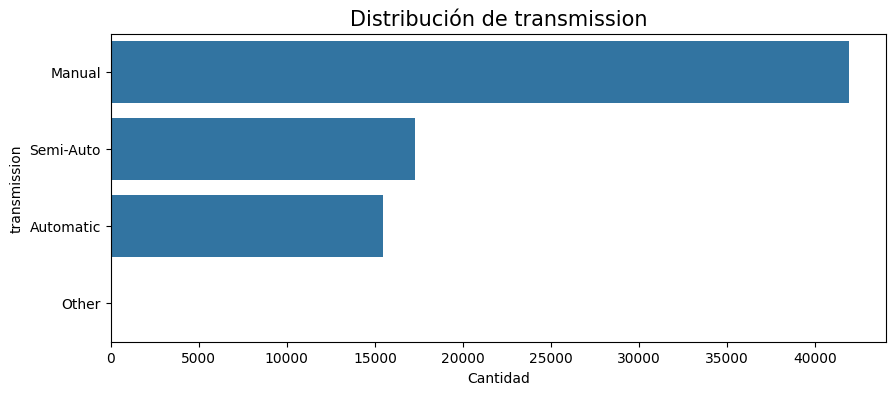

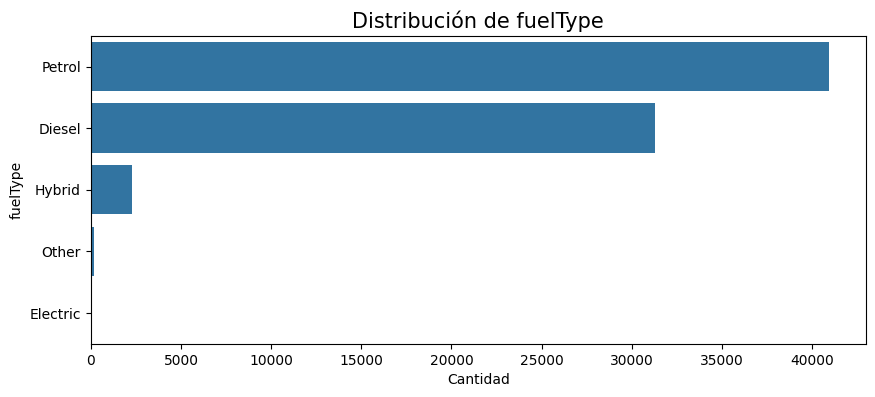

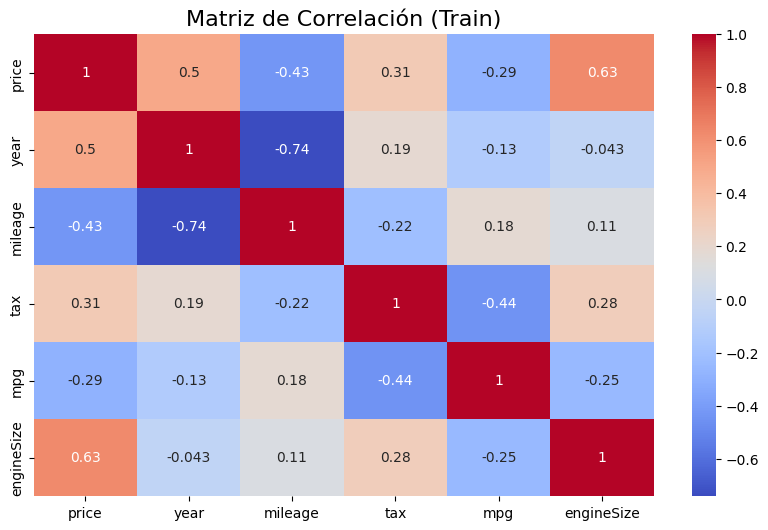

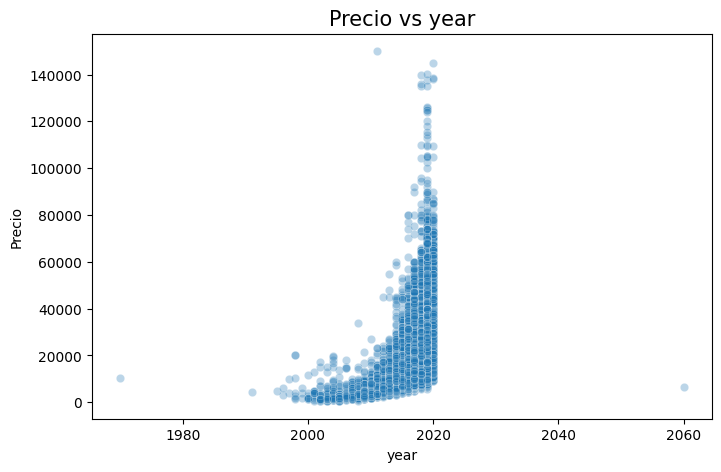

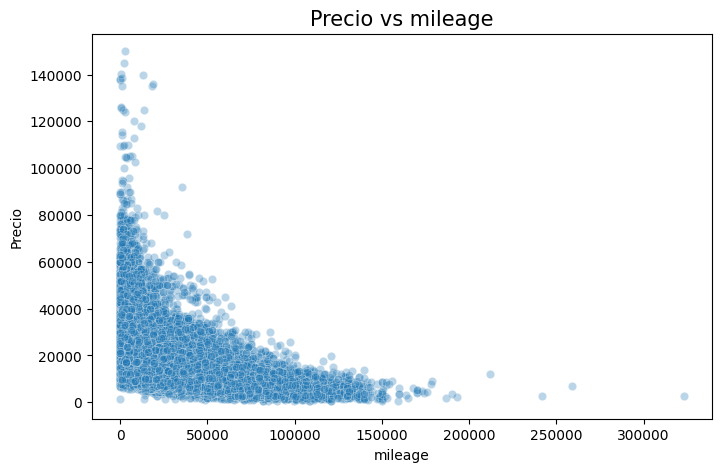

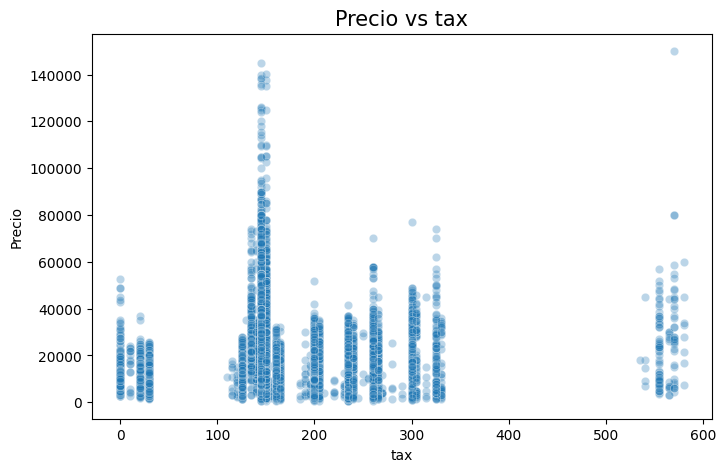

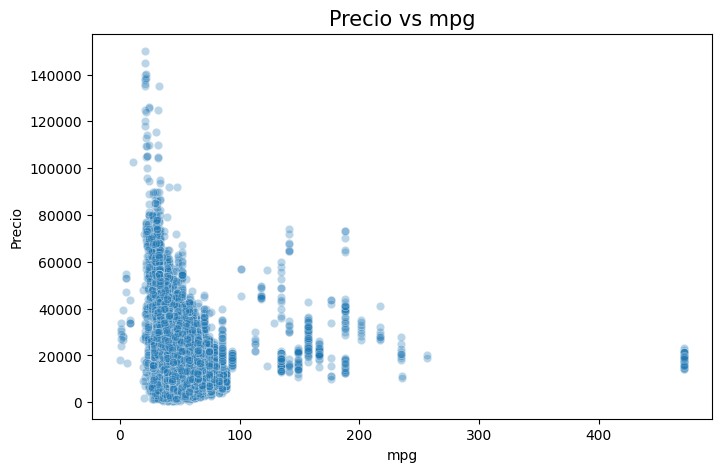

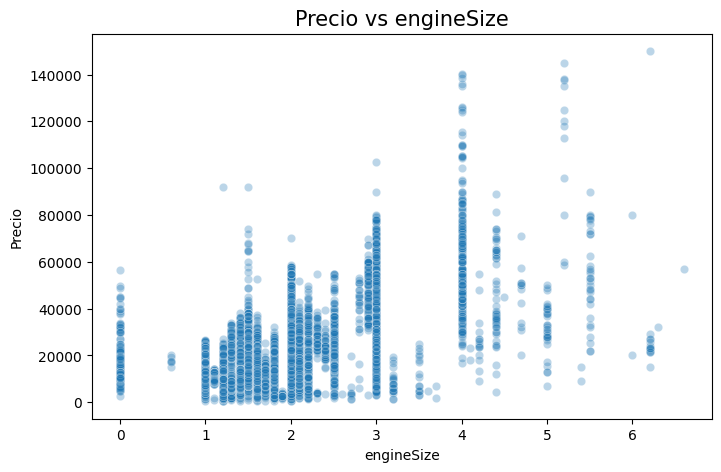

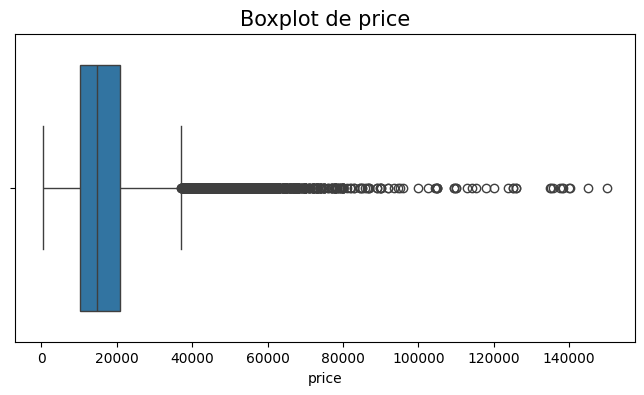

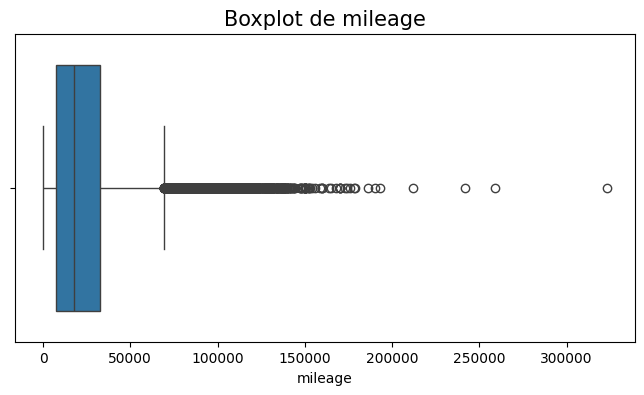

Tamaño inicial antes de eliminar outliers: (74659, 10)
Tamaño después de eliminar outliers en 'price': (71949, 10)
Tamaño después de eliminar outliers en 'mileage': (69089, 10)


In [2]:
# Análisis Exploratorio (EDA) sobre df_train

# 1. Verificar calidad de datos
print("Valores faltantes por columna (train):")
print(df_train.isnull().sum())

# Identificar y eliminar duplicados
duplicados = df_train.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {duplicados}")
df_train = df_train.drop_duplicates().reset_index(drop=True)
print(f"Tamaño del dataset después de eliminar duplicados: {df_train.shape}")

# Análisis de variables numéricas
numeric_cols = ['price', 'year', 'mileage', 'tax', 'mpg', 'engineSize']
df_train[numeric_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle('Distribución de Variables Numéricas (Train)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Análisis de variables categóricas
categorical_cols = ['make', 'model', 'transmission', 'fuelType']
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(y=col, data=df_train, order=df_train[col].value_counts().index[:10])
    plt.title(f'Distribución de {col}', fontsize=15)
    plt.xlabel('Cantidad')
    plt.ylabel(col)
    plt.show()

# Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df_train[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación (Train)', fontsize=16)
plt.show()

# Dispersión de variables importantes con precio
variables_interes = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
for var in variables_interes:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=var, y='price', data=df_train, alpha=0.3)
    plt.title(f'Precio vs {var}', fontsize=15)
    plt.xlabel(var)
    plt.ylabel('Precio')
    plt.show()

# Boxplots para outliers
for col in ['price', 'mileage']:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_train[col])
    plt.title(f'Boxplot de {col}', fontsize=15)
    plt.xlabel(col)
    plt.show()

# Tratamiento de outliers (solo price y mileage)
def eliminar_outliers(df, col, factor=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - factor * IQR
    lim_sup = Q3 + factor * IQR
    return df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]

cols_a_filtrar = ['price', 'mileage']
print(f'Tamaño inicial antes de eliminar outliers: {df_train.shape}')
for col in cols_a_filtrar:
    df_train = eliminar_outliers(df_train, col)
    print(f"Tamaño después de eliminar outliers en '{col}': {df_train.shape}")

In [3]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Copias para no alterar los originales
df_train_proc = df_train.copy()
df_comp_proc = df_competition.copy()

# ---------------------------------------------
# Tratamiento de valores faltantes (solo columnas que existen en ambos)
# ---------------------------------------------
for col in ['tax', 'mpg']:
    mediana = df_train_proc[col].median()
    df_train_proc[col].fillna(mediana, inplace=True)
    df_comp_proc[col].fillna(mediana, inplace=True)  # usar la mediana del train

# ---------------------------------------------
# One-Hot Encoding (manteniendo columnas iguales)
# ---------------------------------------------
categorical_vars = ['make', 'model', 'transmission', 'fuelType']

# Agregamos una columna ficticia en test para evitar problemas de columnas faltantes
df_train_proc['__source__'] = 'train'
df_comp_proc['__source__'] = 'test'

# Unimos los datasets para codificarlos juntos
df_combinado = pd.concat([df_train_proc, df_comp_proc], axis=0)

# Codificación one-hot
df_combinado = pd.get_dummies(df_combinado, columns=categorical_vars, drop_first=True)

# Separar nuevamente
df_train_encoded = df_combinado[df_combinado['__source__'] == 'train'].drop(columns='__source__')
df_comp_encoded = df_combinado[df_combinado['__source__'] == 'test'].drop(columns='__source__')

# Asegurar que df_comp_encoded no tenga 'price'
if 'price' in df_comp_encoded.columns:
    df_comp_encoded = df_comp_encoded.drop(columns='price')


# ---------------------------------------------
# Escalamiento de variables numéricas
# ---------------------------------------------
numeric_vars = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

scaler = StandardScaler()
df_train_encoded[numeric_vars] = scaler.fit_transform(df_train_encoded[numeric_vars])
df_comp_encoded[numeric_vars] = scaler.transform(df_comp_encoded[numeric_vars])  # usar mismo scaler

# ---------------------------------------------
# Separación de X (features) y y (target)
# ---------------------------------------------
X_train = df_train_encoded.drop('price', axis=1)
y_train = df_train_encoded['price']

X_test = df_comp_encoded  # este no tiene 'price'

# Verificación final
print(f"Dimensiones conjunto entrenamiento: {X_train.shape}")
print(f"Dimensiones conjunto prueba (Competition): {X_test.shape}")



Dimensiones conjunto entrenamiento: (69089, 211)
Dimensiones conjunto prueba (Competition): (32562, 211)


C:\Users\Paco\AppData\Local\Temp\ipykernel_32060\2546387709.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_proc[col].fillna(mediana, inplace=True)
C:\Users\Paco\AppData\Local\Temp\ipykernel_32060\2546387709.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir modelos candidatos
modelos = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Usamos MAE como métrica
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Evaluar cada modelo con cross-validation
resultados = {}

for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring=mae_scorer)
    resultados[nombre] = -scores.mean()  # Negamos porque MAE fue pasado como negativo

# Mostrar resultados
print("\nMAE promedio en validación cruzada:")
for modelo, mae in resultados.items():
    print(f"{modelo}: MAE promedio = {mae:.2f}")

# Encontrar el mejor modelo
mejor_modelo = min(resultados, key=resultados.get)
print(f"\nMejor modelo según MAE promedio: {mejor_modelo}")

# Visualización: Comparación de Modelos (MAE promedio)
plt.figure(figsize=(10,6))
sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette="Blues_d")
plt.title("Comparación de Modelos - MAE Promedio (CV)", fontsize=14)
plt.ylabel("MAE Promedio")
plt.xlabel("Modelo")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()




Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits

📊 MAE promedio en CV para modelos afinados:
Random Forest (afinado): MAE = 1079.38
Decision Tree (afinado): MAE = 1289.09
Gradient Boosting (afinado): MAE = 1073.26
Ridge Regression (afinado): MAE = 1817.05
Linear Regression: MAE = 1817.04

🎯 Mejores hiperparámetros encontrados:
Random Forest: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}
Decision Tree: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
Gradient Boosting: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10, 'learning_rate': 0.1}
Ridge Regression: {'alpha': 0.01}


C:\Users\Paco\AppData\Local\Temp\ipykernel_24788\3929493576.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models.keys()), y=list(models.values()), palette='Set2')


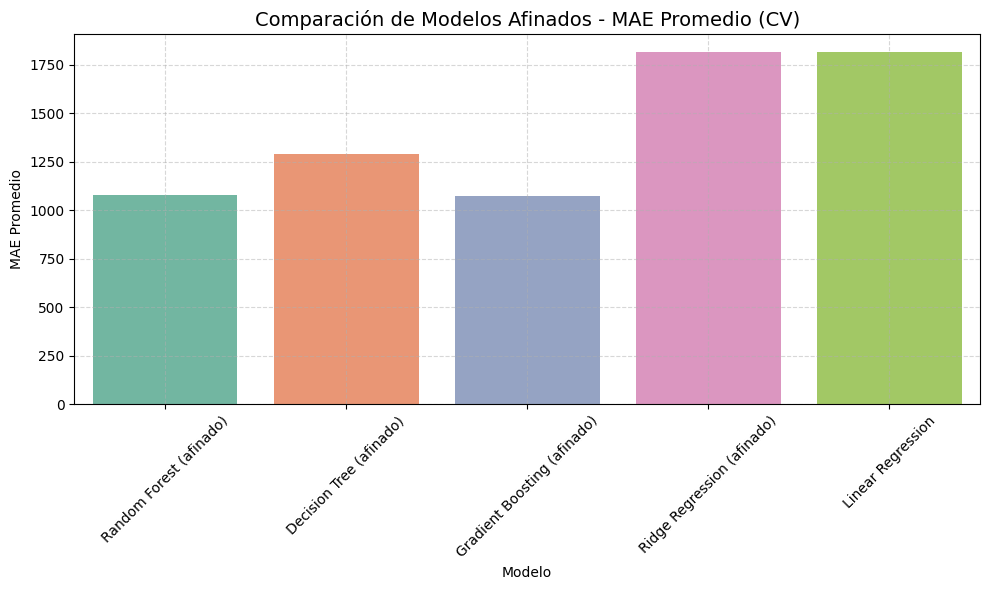

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Scorer
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# -------------------------------------
# 1. Random Forest
# -------------------------------------
rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]  # eliminamos 'auto' que está deprecado
}
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=20, cv=3, scoring=mae_scorer,
                                random_state=42, n_jobs=-1, verbose=1)
rf_search.fit(X_train, y_train)

# -------------------------------------
# 2. Decision Tree
# -------------------------------------
dt = DecisionTreeRegressor(random_state=42)
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_search = RandomizedSearchCV(dt, dt_params, n_iter=15, cv=3, scoring=mae_scorer,
                                random_state=42, n_jobs=-1, verbose=1)
dt_search.fit(X_train, y_train)

# -------------------------------------
# 3. Gradient Boosting
# -------------------------------------
gb = GradientBoostingRegressor(random_state=42)
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}
gb_search = RandomizedSearchCV(gb, gb_params, n_iter=20, cv=3, scoring=mae_scorer,
                                random_state=42, n_jobs=-1, verbose=1)
gb_search.fit(X_train, y_train)

# -------------------------------------
# 4. Ridge Regression
# -------------------------------------
ridge = Ridge()
ridge_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}
ridge_search = RandomizedSearchCV(ridge, ridge_params, n_iter=5, cv=3, scoring=mae_scorer,
                                   random_state=42, n_jobs=-1, verbose=1)
ridge_search.fit(X_train, y_train)

# -------------------------------------
# 5. Linear Regression (sin tuning)
# -------------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

from sklearn.model_selection import cross_val_score
lr_mae = -np.mean(cross_val_score(lr, X_train, y_train, scoring=mae_scorer, cv=3))

# -------------------------------------
# Comparación de modelos
# -------------------------------------
models = {
    'Random Forest (afinado)': -rf_search.best_score_,
    'Decision Tree (afinado)': -dt_search.best_score_,
    'Gradient Boosting (afinado)': -gb_search.best_score_,
    'Ridge Regression (afinado)': -ridge_search.best_score_,
    'Linear Regression': lr_mae
}

print("\n📊 MAE promedio en CV para modelos afinados:")
for modelo, mae in models.items():
    print(f"{modelo}: MAE = {mae:.2f}")

# Hiperparámetros
print("\n🎯 Mejores hiperparámetros encontrados:")
print("Random Forest:", rf_search.best_params_)
print("Decision Tree:", dt_search.best_params_)
print("Gradient Boosting:", gb_search.best_params_)
print("Ridge Regression:", ridge_search.best_params_)

# -------------------------------------
# Visualización
# -------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x=list(models.keys()), y=list(models.values()), palette='Set2')
plt.title('Comparación de Modelos Afinados - MAE Promedio (CV)', fontsize=14)
plt.ylabel('MAE Promedio')
plt.xlabel('Modelo')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




In [ ]:
# Usamos el mejor estimador directamente desde la búsqueda
best_gb = gb_search.best_estimator_

# Entrenar nuevamente sobre todo el train (por si quieres asegurarte)
best_gb.fit(X_train, y_train)

# Predecir precios sobre Competition.csv
y_pred = best_gb.predict(X_test)

# Mostrar algunas predicciones
print("Predicciones para Competition.csv:")
print(y_pred[:10])  # Mostrar primeras 10

# Guardar predicciones en un CSV
df_resultados = pd.DataFrame({
    'id': np.arange(1, len(y_pred) + 1),
    'price': y_pred
})

df_resultados.to_csv('predicciones_competencia.csv', index=False)
print("Predicciones guardadas en 'predicciones_competencia.csv'")


Predicciones para Competition.csv:
[25558.53057047  8410.06659653 20522.7694256  11787.02491751
  9775.86474302  9430.05895667  7261.9317038   6884.90195481
 11380.98952637  9928.81539894]
Predicciones guardadas en 'predicciones_competencia.csv'


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# MAE absoluto ya lo tienes
print(f"MAE (Error absoluto medio): {mae_test:.2f} £")

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Error cuadrático medio): {rmse:.2f} £")

# R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

# MAE en porcentaje (MAPE)
mae_pct = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAE porcentual (MAPE): {mae_pct:.2f} %")

# Real vs Predicho

plt.figure(figsize=(10,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, s=40, color='royalblue', edgecolor='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Línea ideal (y = x)')

plt.xlabel('Precio Real (£)', fontsize=13)
plt.ylabel('Precio Predicho (£)', fontsize=13)
plt.title('Comparación entre Precio Real y Precio Predicho', fontsize=15)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Distribución del error
errores = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(errores, bins=40, kde=True)
plt.title("Distribución del Error (y_test - y_pred)")
plt.xlabel("Error (£)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()



NameError: name 'mae_test' is not defined